# Walmart Store Sales — TFT raw-pipeline inference

This notebook performs inference only:

```text
W&B Registry → self-contained TFT v7 pipeline → pipeline.predict(raw test.csv) → submission artifact
```

It does not download a checkpoint directly, rebuild a `TimeSeriesDataSet`, merge features, calculate the seasonal fallback, or implement top-series logic. Those responsibilities are embedded in the registered raw-input pipeline created in `model_experiment_TFT.ipynb`.


In [1]:
%pip install -q "torch>=2.3,<3" "lightning>=2.3,<3" "pytorch-forecasting>=1.2,<2" "wandb>=0.19,<1" "pandas>=2.2,<3" "numpy>=1.26,<3" "matplotlib>=3.8,<4" "kaggle>=1.7,<2" "cloudpickle>=3,<4"


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.3/425.3 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.5/75.5 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.3/165.3 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 31.0 MB/s eta 0:00:00


In [2]:
from __future__ import annotations

import hashlib
import json
import subprocess
from pathlib import Path

import cloudpickle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import wandb
from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.metrics import MAE


In [3]:

try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception as exc:
    print(f"Not running in Colab or Drive unavailable: {exc}")


Mounted at /content/drive


## Configuration


In [4]:
CONFIG = {
    "data_dir": "/content/drive/MyDrive/walmart_competition_data",
    "output_dir": "/content/drive/MyDrive/walmart_competition_inference/tft",
    "download_dir": "/content/artifacts/tft_raw_pipeline",
    "wandb_entity": "kende23-n-a",
    "wandb_project": "Walmart-Recruiting---Store-Sales-Forecasting",
    "raw_pipeline_registry_uri": "wandb-registry-model/Walmart_TFT_Raw_Pipeline:champion",
    "raw_pipeline_filename": "walmart_tft_raw_pipeline.pkl",
    "submission_artifact_name": "tft-v7-kaggle-submission",
    "submit_to_kaggle": False,
    "kaggle_competition": "walmart-recruiting-store-sales-forecasting",
    "kaggle_message": "TFT v7 W&B registered raw-input pipeline inference",
}
DATA_DIR = Path(CONFIG["data_dir"])
OUTPUT_DIR = Path(CONFIG["output_dir"])
DOWNLOAD_DIR = Path(CONFIG["download_dir"])
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)
CONFIG


{'data_dir': '/content/drive/MyDrive/walmart_competition_data',
 'output_dir': '/content/drive/MyDrive/walmart_competition_inference/tft',
 'download_dir': '/content/artifacts/tft_raw_pipeline',
 'wandb_entity': 'kende23-n-a',
 'wandb_project': 'Walmart-Recruiting---Store-Sales-Forecasting',
 'raw_pipeline_registry_uri': 'wandb-registry-model/Walmart_TFT_Raw_Pipeline:champion',
 'raw_pipeline_filename': 'walmart_tft_raw_pipeline.pkl',
 'submission_artifact_name': 'tft-v7-kaggle-submission',
 'submit_to_kaggle': False,
 'kaggle_competition': 'walmart-recruiting-store-sales-forecasting',
 'kaggle_message': 'TFT v7 W&B registered raw-input pipeline inference'}

## Load raw test data


In [5]:
test_raw = pd.read_csv(DATA_DIR / "test.csv", parse_dates=["Date"])
required_test = {"Store", "Dept", "Date", "IsHoliday"}
missing = sorted(required_test.difference(test_raw.columns))
if missing:
    raise ValueError({"missing_raw_test_columns": missing})
test_raw = test_raw.sort_values(["Store", "Dept", "Date"]).reset_index(drop=True)
print({"rows": len(test_raw), "columns": test_raw.columns.tolist(), "date_range": (str(test_raw.Date.min().date()), str(test_raw.Date.max().date()))})
display(test_raw.head())


{'rows': 115064, 'columns': ['Store', 'Dept', 'Date', 'IsHoliday'], 'date_range': ('2012-11-02', '2013-07-26')}


,Store,Dept,Date,IsHoliday
0,1,1,2012-11-02,False
1,1,1,2012-11-09,False
2,1,1,2012-11-16,False
3,1,1,2012-11-23,True
4,1,1,2012-11-30,False


## Download registered TFT raw-input pipeline


In [6]:
run = wandb.init(
    entity=CONFIG["wandb_entity"],
    project=CONFIG["wandb_project"],
    group="tft-inference",
    job_type="tft_raw_pipeline_inference",
    name="tft_v7_registry_raw_pipeline_inference",
    config=CONFIG,
)
pipeline_artifact = run.use_artifact(CONFIG["raw_pipeline_registry_uri"])
pipeline_dir = Path(pipeline_artifact.download(root=str(DOWNLOAD_DIR)))
pipeline_path = pipeline_dir / CONFIG["raw_pipeline_filename"]
if not pipeline_path.exists():
    candidates = sorted(pipeline_dir.glob("*.pkl"))
    if len(candidates) != 1:
        raise FileNotFoundError({"expected": str(pipeline_path), "candidates": [str(p) for p in candidates]})
    pipeline_path = candidates[0]
with pipeline_path.open("rb") as file:
    pipeline = cloudpickle.load(file)
print({"registry_artifact": pipeline_artifact.name, "pipeline_type": type(pipeline).__name__, "metadata": pipeline.metadata()})


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: kende23 (kende23-n-a) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb:   3 of 3 files downloaded.  


{'registry_artifact': 'Walmart_TFT_Raw_Pipeline:champion', 'pipeline_type': 'TFTRawPipeline', 'metadata': {'pipeline_type': 'TFTRawPipeline', 'top_n_series': 2000, 'stored_history_rows': 421570, 'blend_alpha': 0.35, 'raw_input_columns': ['Date', 'Dept', 'IsHoliday', 'Store'], 'fallback': 'SeasonalNaive52 for non-top/cold-start series'}}


## Predict directly from raw test rows


In [7]:
predictions = np.asarray(pipeline.predict(test_raw), dtype=np.float64)
if len(predictions) != len(test_raw):
    raise ValueError(f"Pipeline returned {len(predictions)} predictions for {len(test_raw)} raw rows.")
if not np.isfinite(predictions).all() or (predictions < 0).any():
    raise ValueError("Pipeline produced invalid predictions.")
prediction_sha256 = hashlib.sha256(predictions.astype(np.float32).tobytes()).hexdigest()
print({"min": float(predictions.min()), "mean": float(predictions.mean()), "max": float(predictions.max()), "sha256": prediction_sha256})


/usr/local/lib/python3.12/dist-packages/pytorch_forecasting/data/timeseries/_timeseries.py:1861: UserWarning: Min encoder length and/or min_prediction_idx and/or min prediction length and/or lags are too large for 18 series/groups which therefore are not present in the dataset index. This means no predictions can be made for those series. First 10 removed groups: [{'__group_id__Store': '1', '__group_id__Dept': '18'}, {'__group_id__Store': '10', '__group_id__Dept': '18'}, {'__group_id__Store': '11', '__group_id__Dept': '18'}, {'__group_id__Store': '12', '__group_id__Dept': '18'}, {'__group_id__Store': '13', '__group_id__Dept': '18'}, {'__group_id__Store': '14', '__group_id__Dept': '18'}, {'__group_id__Store': '15', '__group_id__Dept': '18'}, {'__group_id__Store': '17', '__group_id__Dept': '18'}, {'__group_id__Store': '18', '__group_id__Dept': '18'}, {'__group_id__Store': '19', '__group_id__Dept': '18'}]
  warnings.warn(
INFO: GPU available: True (cuda), used: False
INFO:lightning.pytorc

{'min': 0.0, 'mean': 16458.395627415957, 'max': 300000.0, 'sha256': '96e1018a7573866f81b77c29362bae112aa498fb1b61fedd88aea979d8f7af53'}


## Build and log Kaggle submission


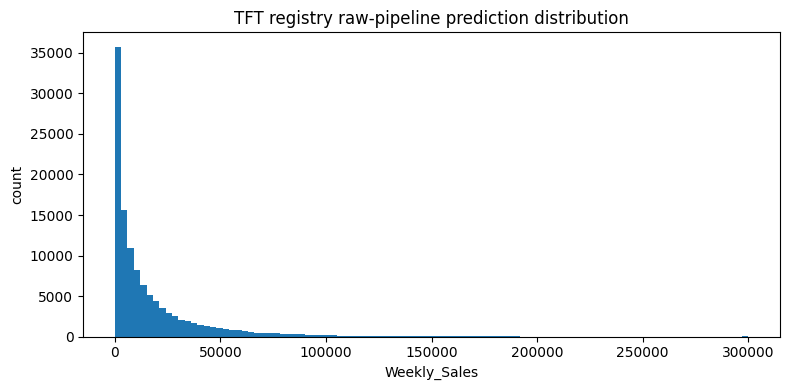

{'submission_path': '/content/drive/MyDrive/walmart_competition_inference/tft/tft_v7_submission_registry_raw_pipeline.csv', 'rows': 115064}


,Id,Weekly_Sales
0,1_1_2012-11-02,38398.054688
1,1_1_2012-11-09,17371.953125
2,1_1_2012-11-16,17956.978516
3,1_1_2012-11-23,19668.685547
4,1_1_2012-11-30,24112.521484


In [10]:
submission = test_raw[["Store", "Dept", "Date"]].copy()
submission["Weekly_Sales"] = predictions
submission.insert(0, "Id", submission["Store"].astype(str) + "_" + submission["Dept"].astype(str) + "_" + submission["Date"].dt.strftime("%Y-%m-%d"))
submission = submission[["Id", "Weekly_Sales"]]
submission_path = OUTPUT_DIR / "tft_v7_submission_registry_raw_pipeline.csv"
submission.to_csv(submission_path, index=False)

manifest = {
    "registry_pipeline_uri": CONFIG["raw_pipeline_registry_uri"],
    "registry_pipeline_artifact": pipeline_artifact.name,
    "pipeline_type": type(pipeline).__name__,
    "pipeline_metadata": pipeline.metadata(),
    "test_rows": int(len(test_raw)),
    "submission_rows": int(len(submission)),
    "prediction_min": float(predictions.min()),
    "prediction_mean": float(predictions.mean()),
    "prediction_max": float(predictions.max()),
    "prediction_sha256": prediction_sha256,
}
manifest_path = OUTPUT_DIR / "tft_raw_pipeline_inference_manifest.json"
manifest_path.write_text(json.dumps(manifest, indent=2))
fig, ax = plt.subplots(figsize=(8, 4)); ax.hist(predictions, bins=100); ax.set_title("TFT registry raw-pipeline prediction distribution"); ax.set_xlabel("Weekly_Sales"); ax.set_ylabel("count"); plt.tight_layout()
hist_path = OUTPUT_DIR / "tft_raw_pipeline_prediction_histogram.png"; fig.savefig(hist_path, dpi=160); plt.show()

run.log({"inference/submission_rows": len(submission), "inference/prediction_min": manifest["prediction_min"], "inference/prediction_mean": manifest["prediction_mean"], "inference/prediction_max": manifest["prediction_max"], "inference/submission_preview": wandb.Table(dataframe=submission.head(2000)), "inference/prediction_histogram": wandb.Image(str(hist_path))})
artifact = wandb.Artifact(CONFIG["submission_artifact_name"], type="submission", metadata=manifest)
for p in [submission_path, manifest_path, hist_path]: artifact.add_file(str(p))
run.log_artifact(artifact, aliases=["registry-raw-pipeline", "latest"])
run.summary.update(manifest)
print({"submission_path": str(submission_path), "rows": len(submission)})
display(submission.head())


## Optional Kaggle submission


In [11]:
if CONFIG["submit_to_kaggle"]:
    cmd = ["kaggle", "competitions", "submit", "-c", CONFIG["kaggle_competition"], "-f", str(submission_path), "-m", CONFIG["kaggle_message"]]
    result = subprocess.run(cmd, capture_output=True, text=True, check=False)
    print(result.stdout); print(result.stderr)
    if result.returncode != 0: raise RuntimeError("Kaggle submission failed")
else:
    print("Kaggle submission skipped. Set CONFIG['submit_to_kaggle'] = True to submit.")
run.finish()


Kaggle submission skipped. Set CONFIG['submit_to_kaggle'] = True to submit.


inference/prediction_max,▁▁▁
inference/prediction_mean,▁▁▁
inference/prediction_min,▁▁▁
inference/submission_rows,▁▁▁
inference/prediction_max,300000
inference/prediction_mean,16458.39563
inference/prediction_min,0
inference/submission_rows,115064
pipeline_type,TFTRawPipeline
prediction_max,300000
prediction_mean,16458.39563
